<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [151]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 
DBNAME = 'удалено'
USER = 'удалено'
PASSWORD = 'удалено'
HOST = 'удалено'
PORT = 5432

In [153]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [154]:
# текст запроса
query_3_1 = f'''
                select count(*) as cnt from vacancies;
            '''

In [155]:
# результат запроса
df_vacancies = pd.read_sql_query(query_3_1, connection)
display(df_vacancies['cnt'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\353529504.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vacancies = pd.read_sql_query(query_3_1, connection)


np.int64(49197)

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [156]:
# текст запроса
query_3_2 = f'''
                select count(*) as cnt from employers;
            '''

In [157]:
# результат запроса
df_epmloyers = pd.read_sql_query(query_3_2, connection)
display(df_epmloyers['cnt'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\4243179891.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_epmloyers = pd.read_sql_query(query_3_2, connection)


np.int64(23501)

3. Посчитате с помощью запроса количество регионов (таблица areas).

In [158]:
# текст запроса
query_3_3 = f'''
                select count(*) as cnt from areas;
            '''

In [159]:
# результат запроса
df_areas = pd.read_sql_query(query_3_3, connection)
display(df_areas['cnt'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2039050790.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_areas = pd.read_sql_query(query_3_3, connection)


np.int64(1362)

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [160]:
# текст запроса
query_3_3 = f'''
                select count(*) as cnt from industries;
            '''

In [161]:
# результат запроса
df_industries = pd.read_sql_query(query_3_3, connection)
display(df_industries['cnt'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\3649602320.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_industries = pd.read_sql_query(query_3_3, connection)


np.int64(294)

***

In [162]:
# выводы по предварительному анализу данных
print('Количество вакансий составляет 49197 шт.\n'
'В среднем в базе две вакансии на одно работодателя(23501)\n'
'Вакансии обнаружены для 1362 регионах и в 294 сферах деятельности.')


Количество вакансий составляет 49197 шт.
В среднем в базе две вакансии на одно работодателя(23501)
Вакансии обнаружены для 1362 регионах и в 294 сферах деятельности.


# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [163]:
# текст запроса
query_4_1 = f'''
                select areas.name, count(vacancies.id) as cnt 
                from vacancies
                left join areas on vacancies.area_id = areas.id 
                group by areas.name
                order by cnt desc
                limit 5;
            '''

In [164]:
# результат запроса
df_vac_areas = pd.read_sql_query(query_4_1, connection)
display(df_vac_areas);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\857941387.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vac_areas = pd.read_sql_query(query_4_1, connection)


,name,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [165]:
# текст запроса
query_4_2 = f'''
                select count(*) as cnt 
                from vacancies
                where salary_from is not null or salary_to is not null;
            '''


In [166]:
# результат запроса
df_vac_salary = pd.read_sql_query(query_4_2, connection)
display(df_vac_salary['cnt'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2967102628.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vac_salary = pd.read_sql_query(query_4_2, connection)


np.int64(24073)

3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [167]:
# текст запроса
query_4_3 = f'''
                select avg(salary_from) as avg_salary_from, avg(salary_to) as avg_salary_to 
                from vacancies;
            '''

In [168]:
# результат запроса
df_mean_vac_salary = pd.read_sql_query(query_4_3, connection)
display(df_mean_vac_salary);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\635775296.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_mean_vac_salary = pd.read_sql_query(query_4_3, connection)


,avg_salary_from,avg_salary_to
0,71064.657901,110536.741923


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [169]:
# текст запроса
query_4_4 = f'''
                select schedule,employment,count(*) as cnt  
                from vacancies
                group by schedule,employment
                order by cnt desc
                ;
            '''

In [170]:
# результат запроса
df_count_vac_shel_emp = pd.read_sql_query(query_4_4, connection)
display(df_count_vac_shel_emp);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2282980719.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_shel_emp = pd.read_sql_query(query_4_4, connection)


,schedule,employment,cnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [171]:
# текст запроса
query_4_5 = f'''
                select experience,count(*) as cnt  
                from vacancies
                group by experience
                order by cnt asc
                ;
            '''

In [172]:
# результат запроса
df_count_vac_exp = pd.read_sql_query(query_4_5, connection)
display(df_count_vac_exp);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\3521554157.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_exp = pd.read_sql_query(query_4_5, connection)


,experience,cnt
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

Выводы:
Наибольшее количество вакансий в крупных городах: Москва, Санкт-Петербург, Минск, Новосибирск, Алматы
У половины вакансий(24073) не указана нижняя или верхняя граница зарплаты.
Среднее значение для нижней границы составляет 71 т.р.
Среднее значение для верхней границы составляет 110 т.р.
Наиболее преподчитаемые условия труда в вакансиях это полный рабочий день с полной занятостью.
Требуемый опыт работы от 1 года до 3 лет указан в большинстве вакансий.
 
Согласно полученным данным наибольшее количество вакансий находятся в области сочетания следующих признаков: 
Город Москва, полный рабочий день с полной занятостью, с опытом раоты от 1 года до 3 лет.


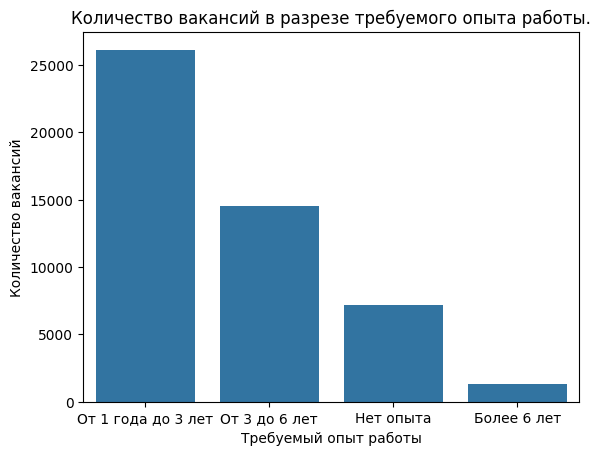

In [173]:
# выводы по детальному анализу вакансий
print('Выводы:\n'
'Наибольшее количество вакансий в крупных городах: Москва, Санкт-Петербург, Минск, Новосибирск, Алматы\n'
'У половины вакансий(24073) не указана нижняя или верхняя граница зарплаты.\n'
'Среднее значение для нижней границы составляет 71 т.р.\n'
'Среднее значение для верхней границы составляет 110 т.р.\n'
'Наиболее преподчитаемые условия труда в вакансиях это полный рабочий день с полной занятостью.\n'
'Требуемый опыт работы от 1 года до 3 лет указан в большинстве вакансий.\n \n'
'Согласно полученным данным наибольшее количество вакансий находятся в области сочетания следующих признаков: \n' 
'Город Москва, полный рабочий день с полной занятостью, с опытом раоты от 1 года до 3 лет.')
# преобразование данных
df_count_vac_exp = df_count_vac_exp.sort_values('cnt',ascending=False)
# построение графика
chart_4_1 = sns.barplot(df_count_vac_exp, x='experience', y='cnt')
chart_4_1.set_title('Количество вакансий в разрезе требуемого опыта работы.')
chart_4_1.set(xlabel="Требуемый опыт работы", ylabel="Количество вакансий");


# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [174]:
# текст запроса
query_5_1 = f'''
                select employers.name, count(vacancies.id) as cnt 
                from vacancies
                left join employers on employers.id = vacancies.employer_id 
                group by employers.name
                order by cnt desc
                limit 5;
                ;
            '''

In [175]:
# результат запроса
df_count_vac_emp = pd.read_sql_query(query_5_1, connection)
display(df_count_vac_emp);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\840555727.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_emp = pd.read_sql_query(query_5_1, connection)


,name,cnt
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [176]:
# текст запроса
query_5_2 = f'''
                select areas_name,emp_cnt,vac_cnt
                from (
                    select areas.name areas_name, count(employers.id) as emp_cnt, count(vacancies.id) as vac_cnt  from areas
                    left join employers on employers.area = areas.id
                    left join vacancies on vacancies.area_id = areas.id
                    group by areas.name
                ) table_itog
                where emp_cnt > 0 and vac_cnt = 0
                order by  emp_cnt desc
                limit 1;
            '''

In [177]:
# результат запроса
df_count_vac_emp_area = pd.read_sql_query(query_5_2, connection)
display(df_count_vac_emp_area['areas_name'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2004127367.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_emp_area = pd.read_sql_query(query_5_2, connection)


'Россия'

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [178]:
# текст запроса
query_5_3 = f'''
                select name_emp, count(area_id) as cnt 
                from (
                    select distinct employers.name as name_emp, area_id  from vacancies 
                    left join employers on employers.id = vacancies.employer_id
                ) table_1
                group by name_emp
                order by cnt desc
                ;
            '''

In [179]:
# результат запроса
df_count_emp_area = pd.read_sql_query(query_5_3, connection)
display(df_count_emp_area);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\697261528.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_emp_area = pd.read_sql_query(query_5_3, connection)


,name_emp,cnt
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
14761,Интеркросс,1
14762,Русская дымка,1
14763,Автономная некоммерческая организация Московск...,1
14764,Транспортный холдинг города Алматы,1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [180]:
# текст запроса
query_5_4 = f'''
                select count(employers.name) as cnt_emp 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                where employers_industries.employer_id is null
                ;
            '''

In [181]:
# результат запроса
df_count_emp_ind = pd.read_sql_query(query_5_4, connection)
display(df_count_emp_ind['cnt_emp'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\627183450.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_emp_ind = pd.read_sql_query(query_5_4, connection)


np.int64(8419)

5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [182]:
# текст запроса
query_5_5 = f'''
                select employers.name, count(employers_industries.employer_id) as cnt_ind 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                group by employers.name
                having count(employers_industries.employer_id) = 4
                order by employers.name;
            '''

In [183]:
# результат запроса
df_count_empname_ind = pd.read_sql_query(query_5_5, connection)
display(df_count_empname_ind['name'][2]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\3877407472.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_empname_ind = pd.read_sql_query(query_5_5, connection)


'2ГИС'

6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [184]:
# текст запроса
query_5_6 = f'''
                select count(employers.name) as cnt_emp 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                left join industries on  industries.id = employers_industries.industry_id 
                    and industries.name = 'Разработка программного обеспечения'
                where industries.name is not null
                ;
            '''

In [185]:
# результат запроса
df_count_emp_ind_soft = pd.read_sql_query(query_5_6, connection)
display(df_count_emp_ind_soft['cnt_emp'][0]);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2577460297.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_emp_ind_soft = pd.read_sql_query(query_5_6, connection)


np.int64(3553)

7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [186]:
# код для получения списка городов-милионников
import requests
import io
# Получение данных
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

response = requests.get(url, headers=headers)
response.encoding = 'utf-8'
# Преобразование данных
tables = pd.read_html(io.StringIO(response.text))
df_town = tables[0]
town_list = list(df_town['Город'])
town_str =  str(town_list).strip('[]')


In [187]:
# текст запроса
query_5_7 = f'''
                select name,cnt_vac from (
                select areas.name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where employers.name = 'Яндекс' and areas.name in ({town_str})
                group by employers.name,areas.name
                union all
                select 'Total' as name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where employers.name = 'Яндекс' and areas.name in ({town_str})
                ) table_itog
                order by cnt_vac asc
                ;
            '''

In [188]:
# результат запроса
df_count_emp_vac = pd.read_sql_query(query_5_7, connection)
display(df_count_emp_vac);

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\1565996600.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_emp_vac = pd.read_sql_query(query_5_7, connection)


,name,cnt_vac
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Казань,25
6,Ростов-на-Дону,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\4093675287.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_town_vac = pd.read_sql_query(query_conclusions_1, connection)


У работодателя Яндекс наибольшее количество вакансий(1933 шт.). 
В регионе Россия 410 работодателей и отстутсвуют вакансии, возможно этот регион является аномалией. 
Наибольшее количество регионов(181) с вакансиями у работодателя Яндекса. 
35% работодателей не указали сферу деятельности. 
Только 15% работодателей занимаются разработкой программного обеспечения. 
Количество вакансий работодателя Яндекс в городах миллиониках составляет только 22% от вакансий во всех регионах. 



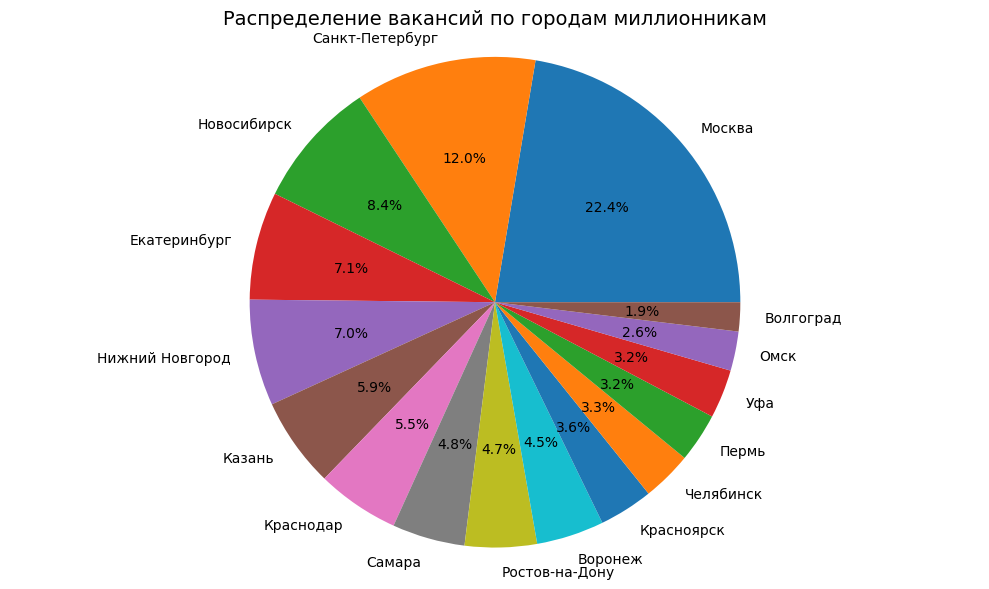

In [189]:
# выводы по анализу работодателей
print('У работодателя Яндекс наибольшее количество вакансий(1933 шт.). \n'
'В регионе Россия 410 работодателей и отстутсвуют вакансии, возможно этот регион является аномалией. \n'
'Наибольшее количество регионов(181) с вакансиями у работодателя Яндекса. \n'
'35% работодателей не указали сферу деятельности. \n'
'Только 15% работодателей занимаются разработкой программного обеспечения. \n'
'Количество вакансий работодателя Яндекс в городах миллиониках составляет только 22% от вакансий во всех регионах. \n')


# текст запроса
query_conclusions_1 = f'''
                select areas.name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where areas.name in ({town_str})
                group by areas.name
                ;
            '''
#получение данных
df_town_vac = pd.read_sql_query(query_conclusions_1, connection)
# Подготовка данных для графика   
df_count_vac_exp = df_town_vac.sort_values('cnt_vac',ascending=False)
# Создаем круговую диаграмму с помощью matplotlib
plt.figure(figsize=(10, 6))
plt.pie(
x=df_count_vac_exp['cnt_vac'], 
labels=df_count_vac_exp['name'], 
autopct='%1.1f%%'
)
plt.title('Распределение вакансий по городам миллионникам', fontsize=14)
plt.axis('equal')
# Отображаем график
plt.tight_layout()
plt.show()


# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [190]:
# текст запроса
query_6_1 = f'''
                select count(*) as cnt  from vacancies
                where LOWER(name) like '%data%' or LOWER(name) like '%данн%';
            '''

In [191]:
# результат запроса
df_count_vac_data = pd.read_sql_query(query_6_1, connection)
print(f'К данным имеет отношение : {df_count_vac_data['cnt'][0]} вакансий.');

К данным имеет отношение : 1771 вакансий.


C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\3647814361.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_data = pd.read_sql_query(query_6_1, connection)


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [192]:
# текст запроса
query_6_2 = f'''
                select * from (
                select  *  from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        (name like '%ML%' and name not ilike '%HTML%') or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                ) table_itog                        
                where 
                        name ilike '%junior%' or 
                        experience = 'Нет опыта' or
                        employment = 'Стажировка';
            '''

In [193]:
# результат запроса
df_count_vac_data = pd.read_sql_query(query_6_2, connection)
print(f'Для начинающего дата-сайентиста подходящих вакансий: {df_count_vac_data.shape[0]}');

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\805010824.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_data = pd.read_sql_query(query_6_2, connection)


Для начинающего дата-сайентиста подходящих вакансий: 51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [194]:
# текст запроса
query_6_3 = f'''
                select * from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                        and (key_skills ilike '%SQL%' or key_skills ilike '%postgres%');
            '''

In [195]:
# результат запроса
df_count_vac_dt_db = pd.read_sql_query(query_6_3, connection)
print(f'Подходящих вакансий в которых ключевой навык SQL или postgres: {df_count_vac_dt_db.shape[0]}');

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\746702910.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_dt_db = pd.read_sql_query(query_6_3, connection)


Подходящих вакансий в которых ключевой навык SQL или postgres: 229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [196]:
# текст запроса
query_6_4 = f'''
                select * from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                        and key_skills ilike '%Python%';
            '''

In [197]:
# результат запроса
df_count_vac_dt_py = pd.read_sql_query(query_6_4, connection)
print(f'Подходящих вакансий в которых ключевой навык Python: {df_count_vac_dt_py.shape[0]}');

Подходящих вакансий в которых ключевой навык Python: 357


C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\1418734747.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_dt_py = pd.read_sql_query(query_6_4, connection)


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [198]:
# текст запроса
query_6_5 = f'''
                SELECT ROUND(AVG(length(key_skills)-length(replace(key_skills, CHR(9), ''))+1), 2) as skill_count
                FROM vacancies
                WHERE 
                (
                    name ilike '%data scientist%' or 
                    name ilike '%data science%' or
                    name ilike '%исследователь данных%' or
                    ((name like '%ML%') and (name not ilike '%HTML%')) or
                    name ilike '%machine learning%' or
                    name ilike '%машинн%обучен%'                
                )  ;
            '''

In [199]:
# результат запроса
df_count_vac_dt_skill = pd.read_sql_query(query_6_5, connection)
print(f'В средней для DS указывают ключевых навыков: {df_count_vac_dt_skill['skill_count'][0]}');

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\82343416.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_dt_skill = pd.read_sql_query(query_6_5, connection)


В средней для DS указывают ключевых навыков: 6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [200]:
# текст запроса
query_6_6 = f'''
            SELECT experience,
            avg(case 
                when salary_from is null then salary_to
                when salary_to is null then salary_from
                when salary_from is not null and salary_to is not null then (salary_from + salary_to) / 2
                else null
            end ) as salary
            FROM vacancies
            WHERE 
            (
                name ilike '%data scientist%' or 
                name ilike '%data science%' or
                name ilike '%исследователь данных%' or
                ((name like '%ML%') and (name not ilike '%HTML%')) or
                name ilike '%machine learning%' or
                name ilike '%машинн%обучен%'                
            )   and (salary_from is not null or salary_to is not null)
            group by experience ;
            '''

In [201]:
# результат запроса
df_count_vac_dt_salary = pd.read_sql_query(query_6_6, connection)
print(f'В среднем дата-сайентист с опытом работы от 3 до 6 лет может рассчитывать на зарплату: {df_count_vac_dt_salary['salary'][2].round()}');
display(df_count_vac_dt_salary)

В среднем дата-сайентист с опытом работы от 3 до 6 лет может рассчитывать на зарплату: 243115.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\2944000012.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count_vac_dt_salary = pd.read_sql_query(query_6_6, connection)


,experience,salary
0,Нет опыта,74642.857143
1,От 1 года до 3 лет,139674.750000
2,От 3 до 6 лет,243114.666667


***

К работе с данными имеют отношение 1771 вакансии, это около 4% из общего объема вакансий, считаю, что это связано с развивающейся областью обработки данных и в будущем вакансий будет значительно больше.
Для начинающего дата-сайентиста крайне мало вакансий, всего 51.
В среднем от дата-сайентиста в вакансии требуется 7 ключевых навыков, что обуславливает сложность вхождения в профессию дата-сайентиста.
Наиболее распространёнными ключевыми навыками в ваканси дата-сайентиста являются Python, SQL.
Уровень зарплаты опытного дата-сайентиста в среднем достаточно высок и составляет 243 115.
Как мы видим на графике требования к рабочему графику в подовляющем большинстве это полный день, но треть вакансий предлагают удалённую работу.


C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\3224093735.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vac_dt_sched = pd.read_sql_query(query_conclusions_2, connection)


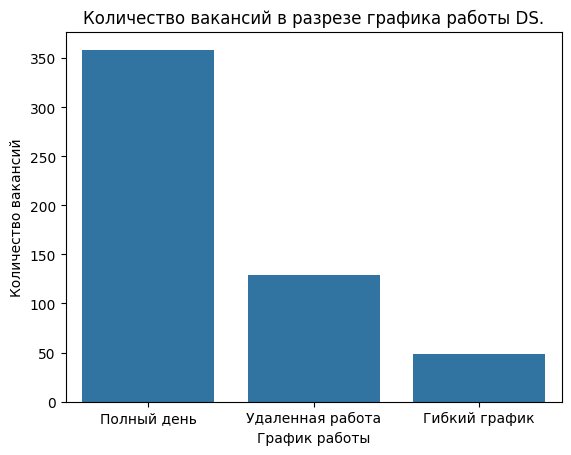

In [202]:
# выводы по предметному анализу
print( 
        'К работе с данными имеют отношение 1771 вакансии, это около 4% из общего объема вакансий, считаю, что это связано с развивающейся областью обработки данных и в будущем вакансий будет значительно больше.\n'
        'Для начинающего дата-сайентиста крайне мало вакансий, всего 51.\n'
        'В среднем от дата-сайентиста в вакансии требуется 7 ключевых навыков, что обуславливает сложность вхождения в профессию дата-сайентиста.\n'
        'Наиболее распространёнными ключевыми навыками в ваканси дата-сайентиста являются Python, SQL.\n'
        'Уровень зарплаты опытного дата-сайентиста в среднем достаточно высок и составляет 243 115.\n'
        'Как мы видим на графике требования к рабочему графику в подовляющем большинстве это полный день, но треть вакансий предлагают удалённую работу.'
      )
# текст запроса
query_conclusions_2 = f'''
            SELECT  schedule, count(id) as cnt
            FROM vacancies
            WHERE 
            (
                name ilike '%data scientist%' or 
                name ilike '%data science%' or
                name ilike '%исследователь данных%' or
                ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                name ilike '%machine learning%' or
                name ilike '%машинн%обучен%'                
            )  
            group by schedule
            order by cnt desc;
            '''
# результат запроса            
df_vac_dt_sched = pd.read_sql_query(query_conclusions_2, connection)
# График
chart_6_1 = sns.barplot(df_vac_dt_sched, x='schedule', y='cnt')
chart_6_1.set_title('Количество вакансий в разрезе графика работы DS.')
chart_6_1.set(xlabel="График работы", ylabel="Количество вакансий");


# Общий вывод по проекту

In [203]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования


#### Выводы
Проанализировано почти 50 тыс. вакансий.<br>
К DS относится около 4% из представленных вакансий.<br>
У работодателя Яндекс наибольшее количество вакансий(1933 шт.) в наибольшем количестве регионов(181).<br>
Наиболее предпочитаемые условия труда в вакансиях это полный рабочий день с полной занятостью.<br>
Требуемый опыт работы от 1 года до 3 лет указан в большинстве вакансий.<br>
<br>
Как видно из графика ниже, наибольшее количество вакансий по поиску Системных администраторов, на втором месте Программист 1С.<br>
Направление дата-сайентиста - не самое популярное, но достаточно высокооплачиваемое, даже для специалистов с небольшим опытом работы. <br>
Наиболее распространёнными ключевыми навыками в вакансии дата-сайентиста являются Python, SQL.<br>
Как видно из второго графика ниже, обнаружено большое различие между населением города и количеством вакансий только в Москве.<br>
В остальных городах данное соотношение линейно.<br>
<br>
Можно провести исследования отвечающие на вопросы ниже:<br>
- В каких специалистах нуждается рынок труда с учётом города? <br>
- Какие ключевые навыки являются самыми востребованными или высокооплачиваемыми? <br>
- Какие медианные зарплаты в различных специализациях и городах?<br>

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\112616747.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vac_top_name = pd.read_sql_query(query_conclusions_2, connection)


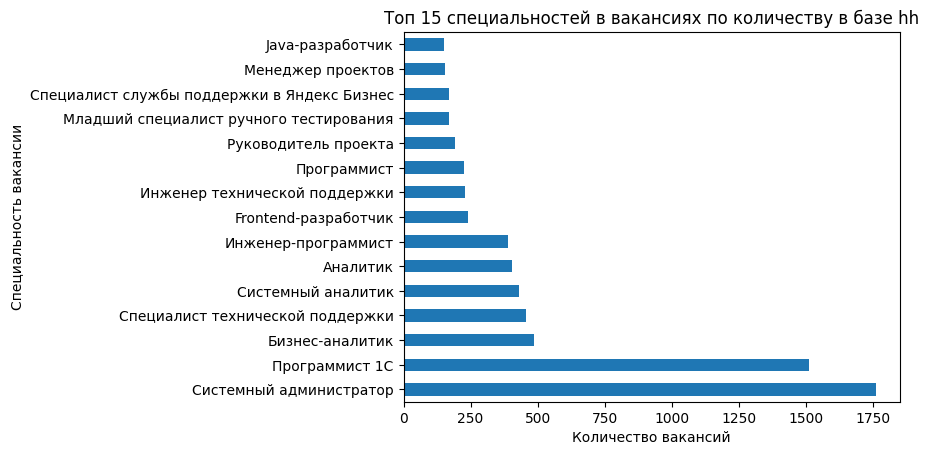

In [204]:
#Анализ количества специальностей вакансий
# текст запроса
query_conclusions_2 = f'''
                            select  name, count(*) as cnt
                            from (
                            select 
                                replace( trim(name), 'Программист 1С', 'Программист 1C' ) as name
                            from vacancies
                            ) table_1
                            group by name
                            order by cnt desc
                            limit 15;
                        '''
# результат запроса               
df_vac_top_name = pd.read_sql_query(query_conclusions_2, connection)
# График
ax = df_vac_top_name.plot.barh(x="name", y="cnt", legend=False)
ax.set_ylabel('Специальность вакансии')
ax.set_xlabel('Количество вакансий')
ax.set_title('Топ 15 специальностей в вакансиях по количеству в базе hh');

C:\Users\Admin\AppData\Local\Temp\ipykernel_19332\4160490923.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vac_top_town = pd.read_sql_query(query_conclusions_3, connection)


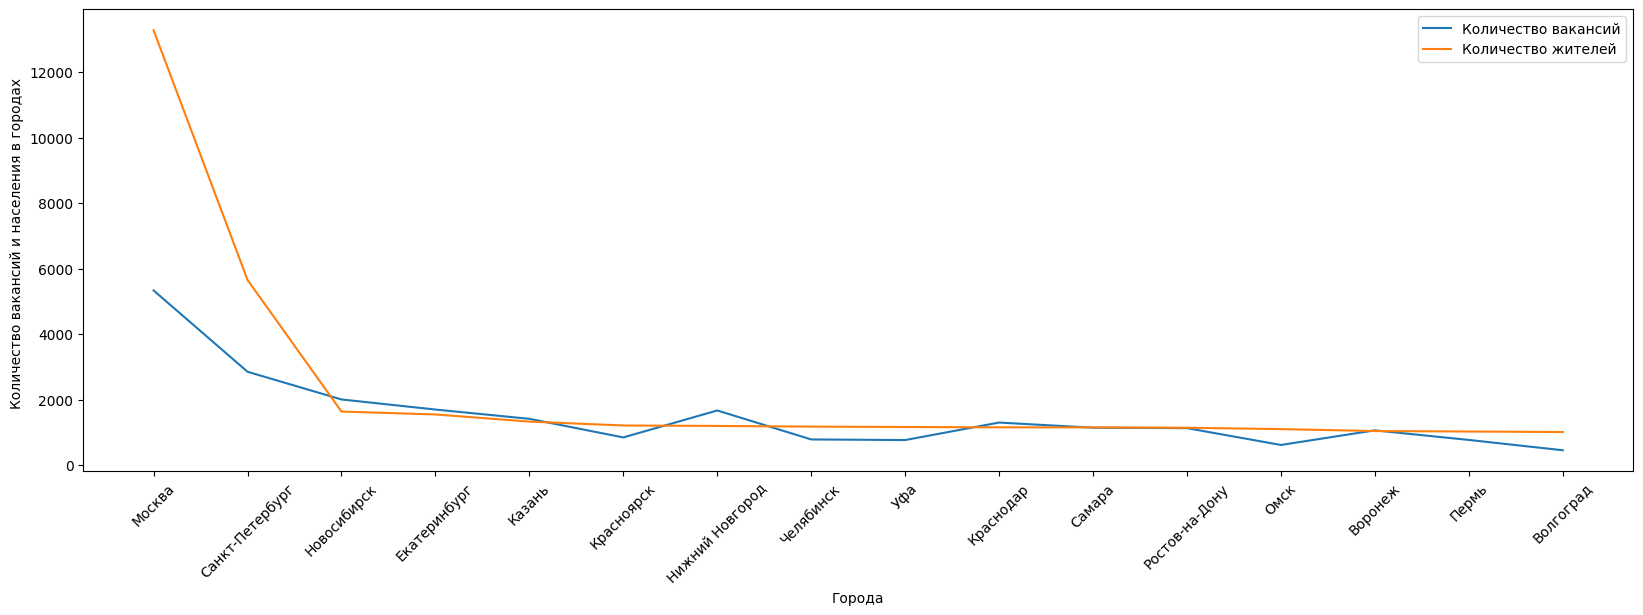

In [205]:
#Анализ количества вакансий в городах миллиониках с учётом количества населения
#Получение данных с сайта
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

response = requests.get(url, headers=headers)
response.encoding = 'utf-8'
tables = pd.read_html(io.StringIO(response.text))
# Преобразование полученных данных
df_town = tables[0]
town_list = list(df_town['Город'])
town_list_col = list(df_town[df_town.columns[2]])
df_town_people = pd.DataFrame({'city': town_list, 'count_people': town_list_col})

# Запрос к БД
query_conclusions_3 = f'''
                            select areas.name, count(vacancies.id) as cnt
                            from vacancies
                                left join areas on areas.id = area_id
                            where areas.name in ({town_str})
                            group by areas.name
                            order by cnt desc;
                        '''
            
            
df_vac_top_town = pd.read_sql_query(query_conclusions_3, connection)
# Объединение полученных данных и преобразование
df_town_people_itog = pd.merge(df_town_people, df_vac_top_town, left_on='city', right_on='name')
df_town_people_itog['count_people'] = df_town_people_itog['count_people'].str.replace(' ', '')
df_town_people_itog['count_people'] = df_town_people_itog['count_people'].astype(int)


#Создаем базовый график
plt.figure(figsize=(20, 6))

#Накладываем первый график
sns.lineplot(x='name', y='cnt', data=df_town_people_itog, label='Количество вакансий')

# Накладываем второй график
sns.lineplot(x='city', y='count_people', data=df_town_people_itog, label='Количество жителей')

# Установить подписи осей и поворот
plt.xlabel("Города")
plt.ylabel("Количество вакансий и населения в городах ")
plt.xticks(rotation=45)

# Добавляем легенду
plt.legend()

# Показываем график
plt.show()

# закрыть соединение c БД после окончания работы
connection.close()
